# OrderFusion+

## 1. Preprocessing

In [1]:
import sys
sys.path.insert(0, 'OrderFusion')  # model.py, preprocessing.py, evaluation.py

from pathlib import Path
import pandas as pd

from preprocessing import SplitDates, load_processed_data, prepare_orderfusion_data
from model import (OrderFusionPlusConfig, TrainingConfig, count_trainable_parameters,
                   plot_training_history, train_orderfusion_plus)
from evaluation import DEFAULT_REPORT_METRICS, evaluate_orderfusion_plus

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / 'data' / 'trade_features_15min_DE_15min.parquet'
COUNTRY = 'DE'
BUCKET_MINUTES = 15
PRODUCT_MINUTES = 15
FEATURE_NAMES = ('VWAP', 'Traded_volume')
ORIGIN = -180
MAX_INPUT_MINUTES = 180
MAX_NEIGHBORS = 12
SCALER_TYPE = 'standard'
LOCAL_TIMEZONE = 'Europe/Berlin'
SPLIT_DATES = SplitDates(
    train_start=pd.Timestamp('2022-01-01', tz=LOCAL_TIMEZONE),
    train_end=pd.Timestamp('2023-09-01', tz=LOCAL_TIMEZONE),
    validation_start=pd.Timestamp('2023-09-01', tz=LOCAL_TIMEZONE),
    validation_end=pd.Timestamp('2024-01-01', tz=LOCAL_TIMEZONE),
    test_start=pd.Timestamp('2024-01-01', tz=LOCAL_TIMEZONE),
    test_end=pd.Timestamp('2024-05-01', tz=LOCAL_TIMEZONE),
)

HIDDEN_DIM = 36
ATTENTION_HEADS = 2
QUANTILES = (0.1, 0.5, 0.9)
TIME_OPTIONS_MINUTES = (15, 30, 60, 120, 180)
NEIGHBOR_OPTIONS = (0, 1, 2, 4, 8, 12)
EPOCHS = 350
BATCH_SIZE = 4096
LEARNING_RATE = 1e-3
SEED = 42
DEVICE = 'auto'
RUN_NAME = f'{COUNTRY}_origin_{ORIGIN}m_seed_{SEED}'
MODEL_DIR = PROJECT_DIR / 'model' / RUN_NAME
RESULT_DIR = PROJECT_DIR / 'result' / RUN_NAME
REPORT_METRICS = DEFAULT_REPORT_METRICS

c:\Users\YuR\AppData\Local\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


### 1.1 What the input data must look like

The modeling code does not read the raw orderbook. It reads one table (a parquet file) in which the trades of every delivery product are already aggregated into 15-minute buckets, separately for the buy side and the sell side. **One row is one delivery product in one bucket.**

| Column | Meaning |
|---|---|
| `Delivery start time` | Delivery start of the product, timezone-aware (UTC) |
| `TimeDelta` | Bucket label in minutes before delivery. `TimeDelta = d` covers the trades from `d` to `d − 15` minutes before delivery start, so `TimeDelta = 15` is the last bucket before delivery |
| `VWAP_buy`, `VWAP_sell` | Volume-weighted average price of the bucket in €/MWh, `NaN` if nothing was traded |
| `Traded_volume_buy`, `Traded_volume_sell` | Traded volume of the bucket in MWh, `0` if nothing was traded |
| `Missing_value_buy`, `Missing_value_sell` | `1` if the bucket has at least one trade, `0` otherwise. Do not forward-fill prices |

Rules: every (`Delivery start time`, `TimeDelta`) pair appears once, and every product needs the buckets up to `|origin| + MAX_INPUT_MINUTES + MAX_NEIGHBORS × 15` minutes before delivery (540 with the settings above), because the history of the neighboring products is read from the same table. Further features listed in `SUPPORTED_FEATURES` (`Number_of_trades`, `Min_price`, `Max_price`) follow the same `<feature>_<side>` naming and are optional.

The next cell imports `make_fake_data` from `OrderFusion/fake_data_generation.py` and builds a **fake** table with exactly this layout from random numbers, so you can see the format without any market data. Set `USE_SYNTHETIC_DATA = True` to run the whole notebook on it as a quick check of your installation; the resulting model is meaningless.

,Delivery start time,TimeDelta,VWAP_buy,Traded_volume_buy,Missing_value_buy,VWAP_sell,Traded_volume_sell,Missing_value_sell
2344,2024-01-01 12:00:00+00:00,120,89.388649,24.144528,1,85.911769,15.179543,1
2345,2024-01-01 12:00:00+00:00,105,88.671547,17.162347,1,85.589363,9.858581,1
2346,2024-01-01 12:00:00+00:00,90,88.645724,70.182348,1,86.671840,20.147662,1
2347,2024-01-01 12:00:00+00:00,75,92.899244,19.217472,1,93.175281,34.284977,1
2348,2024-01-01 12:00:00+00:00,60,90.556551,9.197580,1,88.076583,16.668023,1
2349,2024-01-01 12:00:00+00:00,45,87.052452,26.466791,1,87.351988,18.006471,1
2350,2024-01-01 12:00:00+00:00,30,85.057457,13.438034,1,84.952403,7.115694,1
2351,2024-01-01 12:00:00+00:00,15,80.709245,21.524273,1,80.925327,30.470593,1


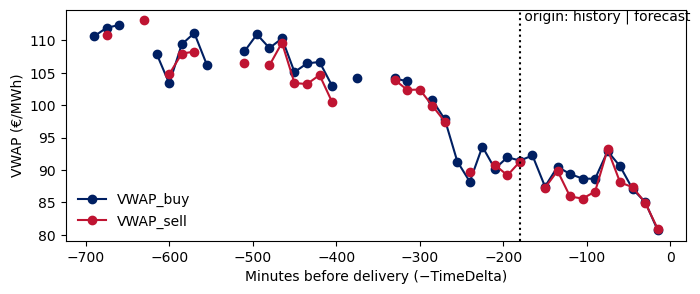

In [4]:
import matplotlib.pyplot as plt
from fake_data_generation import make_fake_data   # OrderFusion/fake_data_generation.py

USE_SYNTHETIC_DATA = True   # True: run the notebook on the fake table below instead of DATA_PATH

example = make_fake_data('2024-01-01', '2024-01-02')
display(example[example['Delivery start time'] == '2024-01-01 12:00:00+00:00'].tail(8))

# One delivery product: the model sees the buckets before the origin and forecasts the buckets after it
one = example[example['Delivery start time'] == '2024-01-01 12:00:00+00:00']
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(-one['TimeDelta'], one['VWAP_buy'], 'o-', color='#001F62', label='VWAP_buy')
ax.plot(-one['TimeDelta'], one['VWAP_sell'], 'o-', color='#BF1432', label='VWAP_sell')
ax.axvline(ORIGIN, color='black', linestyle=':')
ax.text(ORIGIN, ax.get_ylim()[1], ' origin: history | forecast', va='top')
ax.set_xlabel('Minutes before delivery (−TimeDelta)'); ax.set_ylabel('VWAP (€/MWh)'); ax.legend(frameon=False)
plt.show()

In [5]:
if USE_SYNTHETIC_DATA:
    # two fake weeks with short splits and a few epochs, only to check that everything runs
    data = make_fake_data('2024-01-01', '2024-01-15')
    SPLIT_DATES = SplitDates(
        train_start=pd.Timestamp('2024-01-02', tz=LOCAL_TIMEZONE), train_end=pd.Timestamp('2024-01-09', tz=LOCAL_TIMEZONE),
        validation_start=pd.Timestamp('2024-01-09', tz=LOCAL_TIMEZONE), validation_end=pd.Timestamp('2024-01-11', tz=LOCAL_TIMEZONE),
        test_start=pd.Timestamp('2024-01-11', tz=LOCAL_TIMEZONE), test_end=pd.Timestamp('2024-01-14', tz=LOCAL_TIMEZONE),
    )
    EPOCHS, BATCH_SIZE = 3, 256
else:
    data = load_processed_data(DATA_PATH)
display(data.head(5))

,Delivery start time,TimeDelta,VWAP_buy,Traded_volume_buy,Missing_value_buy,VWAP_sell,Traded_volume_sell,Missing_value_sell
0,2024-01-01 00:00:00+00:00,720,NaN,0.000000,0,51.508931,19.897986,1
1,2024-01-01 00:00:00+00:00,705,NaN,0.000000,0,51.716896,20.521281,1
2,2024-01-01 00:00:00+00:00,690,53.405001,15.299754,1,NaN,0.000000,0
3,2024-01-01 00:00:00+00:00,675,NaN,0.000000,0,NaN,0.000000,0
4,2024-01-01 00:00:00+00:00,660,52.066787,17.767723,1,52.769599,26.057480,1


In [6]:
prepared = prepare_orderfusion_data(
    data,
    country=COUNTRY,
    bucket_minutes=BUCKET_MINUTES,
    product_minutes=PRODUCT_MINUTES,
    origins=(ORIGIN,),
    max_input_minutes=MAX_INPUT_MINUTES,
    max_neighbors=MAX_NEIGHBORS,
    split_dates=SPLIT_DATES,
    feature_names=FEATURE_NAMES,
    scaler_type=SCALER_TYPE,
    local_timezone=LOCAL_TIMEZONE,
)
display(prepared.summary())
print('Calendar features:', prepared.settings['context_names'])

,split,samples,first_delivery,last_delivery,observed_target_rate,input_shape,target_shape
0,train,672,2024-01-01 23:00:00+00:00,2024-01-08 22:45:00+00:00,0.942770,"(672, 12, 13, 2)","(672, 12, 2)"
1,validation,192,2024-01-08 23:00:00+00:00,2024-01-10 22:45:00+00:00,0.940538,"(192, 12, 13, 2)","(192, 12, 2)"
2,test,288,2024-01-10 23:00:00+00:00,2024-01-13 22:45:00+00:00,0.944010,"(288, 12, 13, 2)","(288, 12, 2)"


Calendar features: ('delivery_time_sin', 'delivery_time_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_of_year_sin', 'month_of_year_cos', 'is_holiday')


## 2. Modeling

In [7]:
MODEL_CONFIG = OrderFusionPlusConfig(
    timesteps=prepared.timesteps,
    products=prepared.products,
    input_channels=prepared.input_channels,
    origin_minutes=ORIGIN,
    bucket_minutes=BUCKET_MINUTES,
    hidden_dim=HIDDEN_DIM,
    attention_heads=ATTENTION_HEADS,
    quantiles=QUANTILES,
    time_options_minutes=TIME_OPTIONS_MINUTES,
    neighbor_options=NEIGHBOR_OPTIONS,
    calendar_features=prepared.context_features,
)
TRAINING_CONFIG = TrainingConfig(
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    seed=SEED,
    device=DEVICE,
    checkpoint_every=10,
    print_every=1,
)

Epoch 001/3 | train 0.450223 | val 0.425215 | best 0.425215 @ 1
Epoch 002/3 | train 0.439838 | val 0.412472 | best 0.412472 @ 2
Epoch 003/3 | train 0.428108 | val 0.396262 | best 0.396262 @ 3
Trainable parameters: 41124


,epoch,training_loss,training_prediction_loss,training_buy_ranking_loss,training_sell_ranking_loss,validation_aql_scaled,epoch_seconds
0,1,0.450223,0.449914,0.000144,0.000165,0.425215,1.013714
1,2,0.439838,0.439084,0.000406,0.000348,0.412472,0.940938
2,3,0.428108,0.426639,0.000811,0.000658,0.396262,0.900423


(<Figure size 600x350 with 1 Axes>,
 <Axes: xlabel='Epoch', ylabel='Scaled loss'>)

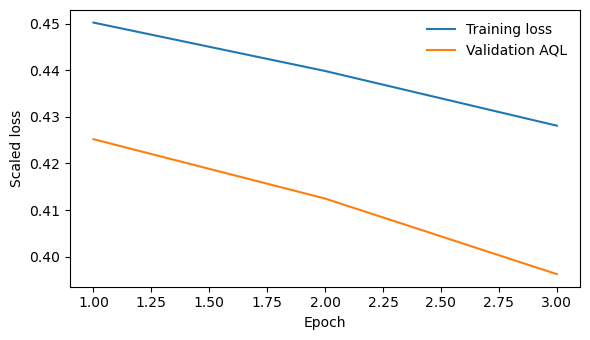

In [8]:
model, history = train_orderfusion_plus(
    prepared, MODEL_CONFIG, TRAINING_CONFIG, output_dir=MODEL_DIR, verbose=True
)
print('Trainable parameters:', count_trainable_parameters(model))
display(history.tail())
plot_training_history(history)

## 3. Evaluation

In [9]:
test_metrics, test_forecasts = evaluate_orderfusion_plus(
    model,
    prepared,
    split_name='test',
    batch_size=BATCH_SIZE,
    metrics=REPORT_METRICS,
    output_dir=RESULT_DIR,
)
display(test_metrics)

,Scope,AQL,AQCE,AQCR,MAE,RMSE,R2
0,Overall,10.543983,0.235223,0.14682,22.503531,28.23129,0.042018
